# README

Notebook que treina e testa o modelo já reduzido

In [1]:
import torch
print("CUDA disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Nome da GPU:", torch.cuda.get_device_name(0))
    print("Versão CUDA do PyTorch:", torch.version.cuda)

CUDA disponível: False


In [2]:
dimension = [8,16]

# Arquitetura 
As entradas foram reduzidas para 8x16. 
É uma rede simples, com uma camada fully connected. 


## Carregar o dataset

In [3]:
from torchvision import datasets, transforms
import os

transform = transforms.Compose([
    transforms.Grayscale(),     
    transforms.Resize((75, 100)),
    transforms.ToTensor()
])

!ls CNN_letter_Dataset/test

test_data  = datasets.ImageFolder(root="CNN_letter_Dataset/test", transform=transform)
train_data  = datasets.ImageFolder(root="CNN_letter_Dataset/train", transform=transform)

# --- DataLoaders ---
train_loader = torch.utils.data.DataLoader(train_data, batch_size=10, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_data, batch_size=10, shuffle=False)

# --- Informações básicas ---
print(f"Total de imagens de treino: {len(train_data)}")
print(f"Total de imagens de teste:  {len(test_data)}")

'ls' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.


Total de imagens de treino: 28400
Total de imagens de teste:  7100


### Normalizar o dataset

In [4]:
import torch.nn.functional as F

interpolate = True
important = False
def interpolate_image(img_tensor, new_dim=dimension):
    """
    Recebe uma imagem [C,H,W] ou [H,W] e retorna vetor [num_top_pixels]
    contendo apenas os pixels mais importantes no novo espaço.
    """
    # Remove canal se necessário
    img = img_tensor.squeeze()  # [H, W]
    img_resized = F.interpolate(
        img.unsqueeze(0).unsqueeze(0),  # adiciona batch e canal
        size=(new_dim[0], new_dim[1]),
        mode='bilinear',
        align_corners=False
    ).squeeze()  # remove batch e canal

    return img_resized.flatten()  

In [5]:
from torch.utils.data import TensorDataset, DataLoader
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reduz conjunto de treino
#X_train_reduced = torch.stack([reduce_image(img, top_pixel_coordinates_int) for img, _ in train_data])
X_train_reduced = torch.stack([interpolate_image(img) for img, _ in train_data])
y_train = torch.tensor([label for _, label in train_data])


# Reduz conjunto de teste
X_test_reduced = torch.stack([interpolate_image(img) for img, _ in test_data])
y_test = torch.tensor([label for _, label in test_data])

print(f"Novo shape de treino: {X_train_reduced.shape}")
print(f"Novo shape de teste:  {X_test_reduced.shape}")

# DataLoaders
batch_size = 10
train_loader_reduced = DataLoader(TensorDataset(X_train_reduced, y_train), batch_size=batch_size, shuffle=True)
test_loader_reduced = DataLoader(TensorDataset(X_test_reduced, y_test), batch_size=batch_size)


Novo shape de treino: torch.Size([28400, 128])
Novo shape de teste:  torch.Size([7100, 128])


In [6]:
for x, y in test_loader:
    print(x.shape)
    break


torch.Size([10, 1, 75, 100])


## Modelo

In [7]:
import torch.nn as nn

num_pixels = dimension[0] * dimension[1]  
n_classes = len(train_data.classes)    

model_small = nn.Sequential(
    nn.Linear(num_pixels, n_classes)
)
print(num_pixels)


128


## Treinamento

In [8]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = "cpu"
model_small.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_small.parameters(), lr=0.1)

epochs = 5
losses_interpolate = []

for epoch in range(epochs):
    print(f'Epoch: {epoch}')
    model_small.train()
    total_loss = 0
    
    for X_batch, y_batch in tqdm(train_loader_reduced):
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        output = model_small(X_batch)
        loss = criterion(output, y_batch)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    

    losses_interpolate.append(total_loss / len(train_loader_reduced))
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader_reduced):.4f}")



Epoch: 0


100%|██████████| 2840/2840 [00:01<00:00, 1586.64it/s]


Epoch 1, Loss: 1.7621
Epoch: 1


100%|██████████| 2840/2840 [00:01<00:00, 1614.82it/s]


Epoch 2, Loss: 0.8888
Epoch: 2


...

Epoch 3, Loss: 0.6966
Epoch: 3


100%|██████████| 2840/2840 [00:05<00:00, 512.91it/s]


Epoch 4, Loss: 0.6002
Epoch: 4


100%|██████████| 2840/2840 [00:06<00:00, 455.04it/s]

Epoch 5, Loss: 0.5408


In [9]:
print(losses_interpolate)

[1.7620520732352432, 0.888794038791052, 0.6965932938414561, 0.600224263992318, 0.5407675534591708]


In [10]:
import numpy as np
import os

# criar pastas caso não existam
os.makedirs("values/weights", exist_ok=True)
os.makedirs("values/bias", exist_ok=True)

weights = model_small[0].weight.data.cpu().numpy()
bias = model_small[0].bias.data.cpu().numpy()

np.save("values/weights/weights_original.npy", weights)
np.save("values/bias/bias_original.npy", bias)
    
np.savetxt("values/weights/weights_original.txt", weights)
np.savetxt("values/bias/bias_original.txt", bias)

## Teste

In [11]:
from torch.utils.data import TensorDataset, DataLoader
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Lista de imagens reduzidas usando as coordenadas corretas
X_test_reduced = torch.stack([interpolate_image(img) for img, _ in test_data])
y_test = torch.tensor([label for _, label in test_data])

print(f"Shape do dataset reduzido: {X_test_reduced.shape}")  # deve ser (N_test, num_top_pixels)

# DataLoader para o modelo reduzido
test_loader_reduced = DataLoader(
    TensorDataset(X_test_reduced, y_test),
    batch_size=10,  # ou outro batch_size que quiser
    shuffle=False
)

Shape do dataset reduzido: torch.Size([7100, 128])


In [12]:
def calc_loss_reduced(model, criterion, loader):
    """
    Calcula a loss média de um modelo MLP que recebe entradas já achatadas.
    loader: DataLoader do dataset reduzido (ex: test_loader_reduced)
    """
    batch_losses = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()
    device = next(model.parameters()).device

    with torch.no_grad():
        for img_batch, label_batch in loader:
            img_batch = img_batch.to(device)
            label_batch = label_batch.to(device)

            output = model(img_batch)
            loss = criterion(output, label_batch).item()
            batch_losses.append(loss)

    mean_loss = sum(batch_losses) / len(batch_losses)
    return batch_losses, mean_loss


In [13]:
batch_losses_interpolate, mean_loss_interpolate = calc_loss_reduced(model_small, criterion, test_loader_reduced)
print(f"Loss média: {mean_loss_interpolate:.4f}")
print(f"Loss por batch (primeiros 5): {batch_losses_interpolate[:10]}")


Loss média: 0.5333
Loss por batch (primeiros 5): [0.904338538646698, 1.238558053970337, 1.298216462135315, 0.4897185266017914, 2.005659818649292, 0.878520131111145, 1.0441786050796509, 1.2003053426742554, 0.7307286262512207, 1.0317052602767944]


In [14]:
def calc_accuracy_reduced(model, loader, n_classes=None):
    """
    Calcula acurácia geral e por classe de um modelo MLP.
    loader: DataLoader do dataset reduzido.
    n_classes: número de classes (se None, inferido do loader).
    """
    if n_classes is None:
        n_classes = len(loader.dataset.tensors[1].unique())
    
    correct_total = 0
    total_total = 0
    correct_per_class = {i: 0 for i in range(n_classes)}
    total_per_class = {i: 0 for i in range(n_classes)}
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()
    device = next(model.parameters()).device

    with torch.no_grad():
        for img_batch, label_batch in loader:
            img_batch = img_batch.to(device)
            label_batch = label_batch.to(device)

            output = model(img_batch)
            preds = output.argmax(dim=1)

            correct_total += (preds == label_batch).sum().item()
            total_total += len(label_batch)

            for i in range(len(label_batch)):
                label = label_batch[i].item()
                total_per_class[label] += 1
                if preds[i] == label_batch[i]:
                    correct_per_class[label] += 1

    class_acc = {cls: correct_per_class[cls]/total_per_class[cls] 
                 if total_per_class[cls] > 0 else 0
                 for cls in range(n_classes)}

    overall_acc = correct_total / total_total
    return overall_acc, class_acc


In [15]:
overall_acc_interpolate, class_acc_interpolate = calc_accuracy_reduced(model_small, test_loader_reduced)
print(f"Acurácia geral: {overall_acc_interpolate*100:.2f}%")
for cls, acc in class_acc_interpolate.items():
    print(f"Classe {cls}: {acc*100:.2f}%")

Acurácia geral: 88.04%
Classe 0: 67.96%
Classe 1: 77.67%
Classe 2: 87.86%
Classe 3: 93.20%
Classe 4: 96.12%
Classe 5: 96.60%
Classe 6: 87.86%
Classe 7: 93.69%
Classe 8: 65.53%
Classe 9: 89.81%
Classe 10: 86.63%
Classe 11: 80.10%
Classe 12: 93.63%
Classe 13: 98.51%
Classe 14: 97.52%
Classe 15: 93.63%
Classe 16: 97.55%
Classe 17: 92.16%
Classe 18: 52.48%
Classe 19: 95.15%
Classe 20: 93.56%
Classe 21: 95.54%
Classe 22: 96.08%
Classe 23: 90.20%
Classe 24: 87.62%
Classe 25: 79.70%
Classe 26: 92.65%
Classe 27: 82.35%
Classe 28: 82.84%
Classe 29: 89.11%
Classe 30: 84.95%
Classe 31: 96.04%
Classe 32: 91.09%
Classe 33: 79.21%
Classe 34: 99.38%


In [16]:
overall_acc_interpolate, class_acc_interpolate = calc_accuracy_reduced(model_small, test_loader_reduced)

# Nome do arquivo
output_file = "values/accuracy/original.txt"

with open(output_file, "w") as f:
    f.write(f"Acurácia geral: {overall_acc_interpolate*100:.2f}%\n\n")
    f.write("Acurácia por classe:\n")
    for cls, acc in class_acc_interpolate.items():
        f.write(f"Classe {cls}: {acc*100:.2f}%\n")

print("Acurácia salva em:", output_file)


Acurácia salva em: values/accuracy/original.txt


# Normalização e Quantização dos pesos

Quantizar int8 (-128 até +128)

In [19]:
import torch
import numpy as np

def quantize_int8_symmetric(weights):
    max_val = torch.max(torch.abs(weights))
    scale = max_val / 127
    w_int8 = torch.round(weights / scale).to(torch.int8)
    return w_int8, scale

linear = model_small[0]

W = linear.weight.data

W_int8, W_scale = quantize_int8_symmetric(W)

np.savetxt("values2/pesos/original.txt", W.cpu().numpy(), fmt="%.8f")
np.savetxt("values2/pesos/int8.txt", W_int8.cpu().numpy(), fmt="%d")

print("Escala usada na quantização:", W_scale)


Escala usada na quantização: tensor(0.0211)


In [24]:
import numpy as np
import torch

def int8_to_bits(w_int8):
    """
    Converte tensor int8 para strings de 8 bits (complemento de 2),
    evitando OverflowError.
    """
    w_np = w_int8.cpu().numpy().astype(np.int8)

    # Operação segura: força para 8 bits com AND 0xFF
    to_bits = np.vectorize(lambda x: format((int(x) & 0xFF), '08b'))

    return to_bits(w_np)
bits = int8_to_bits(W_int8)

print(bits)          # imprime como strings "01010110"
print(bits.shape)    # mesmo shape dos pesos

np.savetxt("values2/pesos/8bits.txt", bits, fmt="%s")


[['00001001' '00010110' '00100000' ... '11101110' '11100111' '11010000']
 ['00001101' '00010001' '00001101' ... '11111010' '11111111' '00000101']
 ['00001000' '00001110' '00001100' ... '11110110' '11110011' '11110101']
 ...
 ['00001011' '00000011' '00000011' ... '11111100' '11111111' '00000011']
 ['11111001' '11111000' '00000000' ... '00000000' '11111111' '00000010']
 ['11110010' '11110001' '11101000' ... '11110011' '11111111' '00000001']]
(35, 128)


In [42]:
import torch
import numpy as np

def quantize_int4_symmetric(weights):
    # Faixa do int4 assinado
    qmin = -8
    qmax = 7
    max_val = torch.max(torch.abs(weights))
    scale = max_val / qmax

    # quantização
    w_int4 = torch.round(weights / scale)

    # clamp para garantir que está dentro da faixa int4
    w_int4 = torch.clamp(w_int4, qmin, qmax)

    # converter para int8 (não existe dtype int4)
    w_int4 = w_int4.to(torch.int8)
    return w_int4, scale


linear = model_small[0]       # camada linear
W = linear.weight.data        # pesos originais

# quantização para 4 bits
W_int4, W_scale = quantize_int4_symmetric(W)

# salvar arquivos
np.savetxt("values2/pesos/int4.txt", W_int4.cpu().numpy(), fmt="%d")

print("Escala usada na quantização (INT4):", W_scale)
print("Min quantizado:", W_int4.min().item(), " | Max quantizado:", W_int4.max().item())


Escala usada na quantização (INT4): tensor(0.3831)
Min quantizado: -7  | Max quantizado: 7


In [43]:
def int4_to_bits(x):
    assert -8 <= x <= 7
    return format(x & 0b1111, "04b")

with open("values2/pesos/int4_bits.txt", "w") as f:
    for row in W_int4:
        bits = [int4_to_bits(int(v)) for v in row]
        f.write(" ".join(bits) + "\n")


In [17]:
import torch
import numpy as np

def quantize_int2_symmetric(weights):
    """
    Quantização simétrica para INT2 (valores -2, -1, 0, 1).
    """
    qmin = -2
    qmax = 1   # signed 2 bits

    # maior valor absoluto dos pesos originais
    max_val = torch.max(torch.abs(weights))

    # escala simétrica
    scale = max_val / qmax   # divide por 1 → ok

    # quantização
    w_int2 = torch.round(weights / scale)

    # clamp para garantir faixa int2
    w_int2 = torch.clamp(w_int2, qmin, qmax)

    # salvar como int8 (não existe dtype int2)
    w_int2 = w_int2.to(torch.int8)

    return w_int2, scale

linear = model_small[0]
W = linear.weight.data

# quantizar para 2 bits
W_int2, W_scale = quantize_int2_symmetric(W)

np.savetxt("values2/pesos/int2.txt", W_int2.cpu().numpy(), fmt="%d")

print("Escala usada na quantização INT2:", W_scale)
print("Faixa observada → min:", W_int2.min().item(), "max:", W_int2.max().item())


Escala usada na quantização INT2: tensor(2.6333)
Faixa observada → min: -1 max: 1


Quantização bits

# Quantização dataset


In [19]:
def quantize_input_int8(x):
    """
    Quantiza um tensor de entrada (float) para int8 usando quantização simétrica.
    """
    max_val = torch.max(torch.abs(x))
    scale = max_val / 127

    x_int8 = torch.round(x / scale).to(torch.int8)
    return x_int8, scale

X_reduced_int8, X_reduced_scale = quantize_input_int8(X_test_reduced)

np.savetxt("values2/input/original.txt", X_test_reduced.cpu().numpy(), fmt="%.8f")
np.savetxt("values2/input/entrada_int8.txt", X_reduced_int8.cpu().numpy(), fmt="%d")

print("Escala usada na quantização da entrada:", X_reduced_scale)

Escala usada na quantização da entrada: tensor(0.0077)


In [20]:
import numpy as np
import torch

def int8_to_bits(w_int8):
    """
    Converte tensor int8 para strings de 8 bits (complemento de 2),
    evitando OverflowError.
    """
    w_np = w_int8.cpu().numpy().astype(np.int8)

    # Operação segura: força para 8 bits com AND 0xFF
    to_bits = np.vectorize(lambda x: format((int(x) & 0xFF), '08b'))

    return to_bits(w_np)
bits = int8_to_bits(X_reduced_int8)

print(bits)          # imprime como strings "01010110"
print(bits.shape)    # mesmo shape dos pesos

np.savetxt("values2/input/entrada_8bits.txt", bits, fmt="%s")


[['01011001' '01011001' '01010111' ... '01100111' '01100101' '01100110']
 ['01001011' '01001011' '01001010' ... '01010110' '01010110' '01010111']
 ['01010101' '01010101' '01010110' ... '01011111' '01100001' '01100000']
 ...
 ['01011001' '01011000' '01011000' ... '01010101' '01000000' '01010001']
 ['01001111' '01010000' '01001110' ... '01001110' '01001110' '01001101']
 ['01000000' '00111111' '00111110' ... '01001111' '01010101' '01011001']]
(7100, 128)


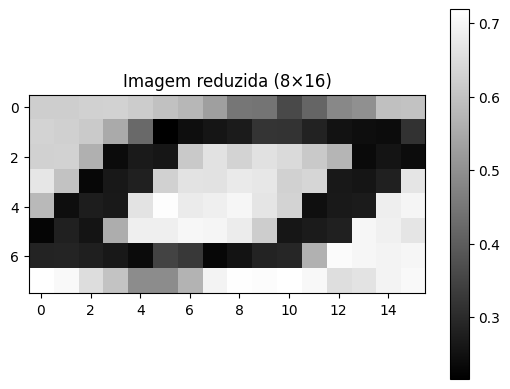

In [34]:
import matplotlib.pyplot as plt

# Pegue a 1ª imagem (ou escolha outro índice)
img = X_train_reduced[0].cpu().numpy()

# Reshape para 8x16
img = img.reshape(8, 16)

plt.imshow(img, cmap="gray")
plt.title("Imagem reduzida (8×16)")
plt.colorbar()
plt.show()


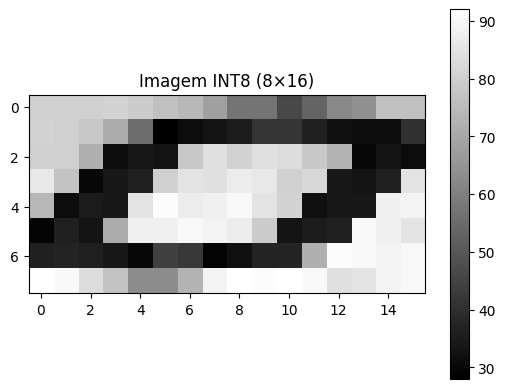

In [35]:
img = X_reduced_int8[0].cpu().numpy().reshape(8, 16)

plt.imshow(img, cmap="gray")
plt.title("Imagem INT8 (8×16)")
plt.colorbar()
plt.show()


In [44]:
import torch
import numpy as np

def quantize_input_int4(x):
    """
    Quantiza entradas (float) para INT4 usando quantização simétrica.
    """
    qmin = -8   # int4 mínimo
    qmax = 7    # int4 máximo

    # maior valor absoluto do tensor
    max_val = torch.max(torch.abs(x))

    # escala simétrica
    scale = max_val / qmax

    # quantiza
    x_int4 = torch.round(x / scale)

    # clamp para garantir que está na faixa int4
    x_int4 = torch.clamp(x_int4, qmin, qmax)

    # não existe int4 → representamos como int8
    x_int4 = x_int4.to(torch.int8)

    return x_int4, scale


X_reduced_int4, X_reduced_scale = quantize_input_int4(X_test_reduced)

np.savetxt("values2/input/entrada_int4.txt", X_reduced_int4.cpu().numpy(), fmt="%d")

print("Escala usada na quantização INT4 da entrada:", X_reduced_scale)
print("Min:", X_reduced_int4.min().item(), "Max:", X_reduced_int4.max().item())



Escala usada na quantização INT4 da entrada: tensor(0.1396)
Min: 0 Max: 7


In [18]:
import torch
import numpy as np

def quantize_input_int2(x):
    """
    Quantiza entradas (float) para INT2 usando quantização simétrica.
    Faixa: -2, -1, 0, 1
    """
    qmin = -2
    qmax = 1

    # maior valor absoluto do tensor
    max_val = torch.max(torch.abs(x))

    # escala simétrica
    scale = max_val / qmax  # igual ao int4, mas com qmax = 1

    # quantiza
    x_int2 = torch.round(x / scale)

    # clamp para garantir valores válidos do INT2
    x_int2 = torch.clamp(x_int2, qmin, qmax)

    # armazenar como int8 (não existe int2)
    x_int2 = x_int2.to(torch.int8)

    return x_int2, scale

X_reduced_int2, X_reduced_scale = quantize_input_int2(X_test_reduced)

np.savetxt("values2/input/entrada_int2.txt", 
           X_reduced_int2.cpu().numpy(), fmt="%d")

print("Escala usada na quantização INT2 da entrada:", X_reduced_scale)
print("Min:", X_reduced_int2.min().item(), "Max:", X_reduced_int2.max().item())


Escala usada na quantização INT2 da entrada: tensor(0.9772)
Min: 0 Max: 1
